In [ ]:
# Changes made by Noah Russell
# Code adopted from https://github.com/mawippel/python-vacuum.
# Changes are made to reflect random agent moves.
# Random Agent. Agent makes random move (-1 for each move, and +10 for clean a spot)

import matplotlib.pyplot as plt
import numpy as np
import random

# =========================
# HW1 Q8: switch to a 6x6 BOARD (cleanable area)
# NOTE: This code uses a wall border, so we store an (INNER+2) x (INNER+2) matrix.
# =========================
INNER = 6               # cleanable area is 6x6
SIZE = INNER + 2        # add 1-cell wall border on all sides

random.seed(0)          # deterministic runs for grading

# 0 -> clean
# 1 -> wall
# 2 -> dirt
# Probability matrix used to generate the environment.
# Border is walls (=1.0). Interior are probabilities in [0,1].
matrix = [[1.0]*SIZE for _ in range(SIZE)]
for i in range(1, INNER+1):
    for j in range(1, INNER+1):
        matrix[i][j] = 0.2  # default dirt probability

# (Optional) add a little structure so the map isn't uniform
for (i, j, p) in [(1, 4, 0.5), (2, 5, 0.6), (3, 2, 0.4), (4, 3, 0.6), (5, 1, 0.4), (6, 6, 0.5)]:
    if 1 <= i <= INNER and 1 <= j <= INNER:
        matrix[i][j] = p


def createWorld(m):
    """Create environment. Each run generates dirt based on the probability matrix."""
    for r in range(1, INNER+1):
        for c in range(1, INNER+1):
            m[r][c] = 2 if (random.random() < m[r][c]) else 0


# Actions = up (0), down (1), left (2), right (3), clean (4), idle (6)
def findNextAction(x, y):
    # Use INNER instead of hard-coded 5x5 limits
    if x == 1 and y == 1:  # top-left corner
        return random.choice([1, 3, 6])
    elif x == 1 and y == INNER:  # top-right corner
        return random.choice([1, 2, 6])
    elif x == INNER and y == 1:  # bottom-left corner
        return random.choice([0, 3, 6])
    elif x == INNER and y == INNER:  # bottom-right corner
        return random.choice([0, 2, 6])
    elif x == 1:
        return random.choice([1, 2, 3, 6])
    elif x == INNER:
        return random.choice([0, 2, 3, 6])
    elif y == 1:
        return random.choice([0, 1, 3, 6])
    elif y == INNER:
        return random.choice([0, 1, 2, 6])
    else:
        return random.choice([0, 1, 2, 3, 6])


def renderMatrix(matrix, x, y, utility, timeElapsed):
    plt.text(0, 0, "Time Elapsed:%d; Utility: %.1f" % (timeElapsed, utility))
    plt.imshow(matrix, 'pink')
    plt.show(block=False)
    plt.plot(y, x, 'r:', linewidth=1)
    plt.plot(y[-1], x[-1], '*r', 'Robot field', 5)
    plt.pause(0.5)
    plt.clf()


# decides which action will be done
def simpleAgentRobot(x, y):
    if matrix[x][y] == 2:  # if it's dirty, clean
        return 4
    return findNextAction(x, y)


def checkDirtSpots(matrix):
    # counts dirt cells (value 2) in the interior
    return sum(1 for r in range(1, INNER+1) for c in range(1, INNER+1) if matrix[r][c] == 2)


def main():
    createWorld(matrix)
    print("Environment (beginning)\n")
    print('\n'.join(['\t'.join([str(cell) for cell in row]) for row in matrix]))

    # robot always starts at [1][1]
    currLine, currCol = 1, 1
    Lines, Cols = [currLine], [currCol]

    utility = 0
    timeElapsed = 0
    renderMatrix(matrix, Lines, Cols, utility, timeElapsed)

    while True:
        action = simpleAgentRobot(currLine, currCol)

        if action == 0:  # up
            currLine -= 1
            utility -= 1
        elif action == 1:  # down
            currLine += 1
            utility -= 1
        elif action == 2:  # left
            currCol -= 1
            utility -= 1
        elif action == 3:  # right
            currCol += 1
            utility -= 1
        elif action == 4:  # clean
            matrix[currLine][currCol] = 0
            utility += 10
        elif action == 6:  # idle
            utility += 0
        else:
            break

        Lines.append(currLine)
        Cols.append(currCol)
        timeElapsed += 1
        renderMatrix(matrix, Lines, Cols, utility, timeElapsed)

        # (Optional safety stop so it doesn't run forever)
        if timeElapsed >= 250:
            break

    print(f"Environment (ending): {utility:.1f}\n")
    print('\n'.join(['\t'.join([str(cell) for cell in row]) for row in matrix]))


if __name__ == "__main__":
    main()


In [ ]:
# CAP 6635 Artificial Intelligence; X. Zhu; 01/13/2022
# Changes made by Noah Russell
# Code adopted from https://github.com/mawippel/python-vacuum.
# Changes are made to reflect agent moves following predefined path.
# Reflex Vacuum Cleaner Agent. -1 for each move, and +10 for clean a spot

import matplotlib.pyplot as plt
import numpy as np
import random

# =========================
# HW1 Q8: switch to a 6x6 BOARD (cleanable area)
# This file uses an action table (policy). We generate it automatically for 6x6.
# =========================
INNER = 6
SIZE = INNER + 2

random.seed(0)

# 0 -> clean, 1 -> wall, 2 -> dirt
matrix = [[1.0]*SIZE for _ in range(SIZE)]
for i in range(1, INNER+1):
    for j in range(1, INNER+1):
        matrix[i][j] = 0.2

# Actions Matrix:
# Actions = up (0), down (1), left (2), right (3), clean(4), end (5)
# We generate a serpentine sweep that visits all interior cells then ends.
actionsMatrix = [[9]*SIZE for _ in range(SIZE)]

for r in range(1, INNER+1):
    if r % 2 == 1:  # odd row: move right
        for c in range(1, INNER):
            actionsMatrix[r][c] = 3
        # at right edge: go down unless last row
        actionsMatrix[r][INNER] = 1 if r != INNER else 5
    else:  # even row: move left
        for c in range(2, INNER+1):
            actionsMatrix[r][c] = 2
        actionsMatrix[r][1] = 1 if r != INNER else 5


def renderMatrix(matrix, x, y, utility, timeElapsed):
    plt.text(0, 0, "Time Elapsed:%d; Utility: %.1f" % (timeElapsed, utility))
    plt.imshow(matrix, 'pink')
    plt.show(block=False)
    plt.plot(y, x, 'r:', linewidth=1)
    plt.plot(y[-1], x[-1], '*r', 'Robot Field', 5)
    plt.pause(0.5)
    plt.clf()


def createWorld(m):
    for r in range(1, INNER+1):
        for c in range(1, INNER+1):
            m[r][c] = 2 if (random.random() < m[r][c]) else 0


def findNextAction(x, y):
    return actionsMatrix[x][y]


def modelAgentRobot(x, y):
    if matrix[x][y] == 2:
        return 4
    return findNextAction(x, y)


def checkDirtSpots(matrix):
    return sum(1 for r in range(1, INNER+1) for c in range(1, INNER+1) if matrix[r][c] == 2)


def main():
    createWorld(matrix)
    print("Environment (beginning)\n")
    print('\n'.join(['\t'.join([str(cell) for cell in row]) for row in matrix]))

    currLine, currCol = 1, 1
    Lines, Cols = [currLine], [currCol]
    utility = 0
    timeElapsed = 0

    renderMatrix(matrix, Lines, Cols, utility, timeElapsed)
    print("Initial dirt count:", checkDirtSpots(matrix))

    while True:
        action = modelAgentRobot(currLine, currCol)

        if action == 0:  # up
            currLine -= 1
            utility -= 1
        elif action == 1:  # down
            currLine += 1
            utility -= 1
        elif action == 2:  # left
            currCol -= 1
            utility -= 1
        elif action == 3:  # right
            currCol += 1
            utility -= 1
        elif action == 4:  # clean
            matrix[currLine][currCol] = 0
            utility += 10
        else:
            break

        Lines.append(currLine)
        Cols.append(currCol)
        timeElapsed += 1
        renderMatrix(matrix, Lines, Cols, utility, timeElapsed)

        if timeElapsed >= 250:
            break

    print(f"Environment (ending): {utility:.1f}\n")
    print('\n'.join(['\t'.join([str(cell) for cell in row]) for row in matrix]))


if __name__ == "__main__":
    main()


In [ ]:
# CAP 6635 Artificial Intelligence; X. Zhu; 01/13/2022
# Changes made by Noah Russell
# Code adopted from https://github.com/mawippel/python-vacuum.
# Goal Based Vacuum Cleaner Agent.
# Agent repetitively searches closest dirt and walks to clean it.
# -1 for each move, +10 for cleaning dirt.

import matplotlib.pyplot as plt
import random
from Node import *
from copy import deepcopy

# =========================
# HW1 Q8: switch to a 6x6 BOARD (cleanable area)
# This code uses a wall border, so stored matrix is (INNER+2)x(INNER+2).
# =========================
INNER = 6
SIZE = INNER + 2

random.seed(0)

# 0 -> clean, 1 -> wall, 2 -> dirt
matrix = [[1.0]*SIZE for _ in range(SIZE)]
for i in range(1, INNER+1):
    for j in range(1, INNER+1):
        matrix[i][j] = 0.2

# presentation/process maps are created after world generation
presentationMatrix = None
process_map = None

# robot state
currLine = 1
currCol = 1
stack = [Node(1, 1)]
solution = [Node(1, 1)]


def mapNotClean():
    for i in range(1, len(matrix) - 1):
        for j in range(1, len(matrix[i]) - 1):
            if matrix[i][j] == 2:
                return True
    return False


def renderMatrix(matrix, x, y, utility, timeElapsed):
    plt.text(0, 0, "Time Elapsed:%d; Utility: %.1f" % (timeElapsed, utility))
    plt.imshow(matrix, 'pink')
    plt.show(block=False)
    plt.plot(y, x, 'r:', linewidth=1)
    plt.plot(y[-1], x[-1], '*r', 'Robot Field', 5)
    plt.pause(0.5)
    plt.clf()


def createWorld(m):
    global process_map, presentationMatrix
    for r in range(1, INNER+1):
        for c in range(1, INNER+1):
            m[r][c] = 2 if (random.random() < m[r][c]) else 0
    process_map = deepcopy(m)
    presentationMatrix = deepcopy(m)


def hasPosition(x, y):
    return matrix[x][y] != 1


def lookLeft(x, y, node):
    if hasPosition(x - 1, y):
        new_node = Node(x - 1, y, node)
        if process_map[x - 1][y] == 2:
            return new_node
        if process_map[x - 1][y] != 4:
            stack.append(new_node)
            process_map[x - 1][y] = 4


def lookRight(x, y, node):
    if hasPosition(x + 1, y):
        new_node = Node(x + 1, y, node)
        if process_map[x + 1][y] == 2:
            return new_node
        if process_map[x + 1][y] != 4:
            stack.append(new_node)
            process_map[x + 1][y] = 4


def lookAbove(x, y, node):
    if hasPosition(x, y - 1):
        new_node = Node(x, y - 1, node)
        if process_map[x][y - 1] == 2:
            return new_node
        if process_map[x][y - 1] != 4:
            stack.append(new_node)
            process_map[x][y - 1] = 4


def lookDown(x, y, node):
    if hasPosition(x, y + 1):
        new_node = Node(x, y + 1, node)
        if process_map[x][y + 1] == 2:
            return new_node
        if process_map[x][y + 1] != 4:
            stack.append(new_node)
            process_map[x][y + 1] = 4


def discoverPath():
    while len(stack) != 0:
        node = stack.pop(0)
        x = node.get_x()
        y = node.get_y()

        auxNode = lookLeft(x, y, node)
        if auxNode:
            return auxNode

        auxNode = lookAbove(x, y, node)
        if auxNode:
            return auxNode

        auxNode = lookRight(x, y, node)
        if auxNode:
            return auxNode

        auxNode = lookDown(x, y, node)
        if auxNode:
            return auxNode


def main():
    global matrix, process_map, stack, currCol, currLine, solution, presentationMatrix

    createWorld(matrix)

    print("Environment (beginning)\n")
    print('\n'.join(['\t'.join([str(cell) for cell in row]) for row in matrix]))

    currLine, currCol = 1, 1
    utility = 0
    Lines, Cols = [currLine], [currCol]
    timeElapsed = 0

    renderMatrix(matrix, Lines, Cols, utility, timeElapsed)

    # build a full cleaning plan (sequence of Nodes)
    while mapNotClean():
        path = discoverPath()
        x = path.get_x()
        y = path.get_y()

        aux_list = []
        while path.get_parent() is not None:
            process_map[path.get_x()][path.get_y()] = 3
            aux_list.append(path)
            path = path.get_parent()
        aux_list.reverse()
        solution.extend(aux_list)

        matrix[x][y] = 0
        stack = [Node(x, y)]
        process_map = deepcopy(matrix)

    # execute the plan and compute utility
    for node in solution:
        currCol = node.get_y()
        currLine = node.get_x()
        Lines.append(currLine)
        Cols.append(currCol)
        timeElapsed += 1
        renderMatrix(presentationMatrix, Lines, Cols, utility, timeElapsed)

        if presentationMatrix[currLine][currCol] == 2:
            presentationMatrix[currLine][currCol] = 0
            utility += 10
        else:
            utility -= 1

    timeElapsed += 1
    renderMatrix(presentationMatrix, Lines, Cols, utility, timeElapsed)

    # Original code used tkinter messagebox; we print instead (avoids import issues).
    print(f"Summary: Total traveled {len(solution) - 1} steps; Utility={utility:.1f}")


if __name__ == "__main__":
    main()


Current working dir: /content
Files here: ['.config', 'Node.py', '__pycache__', 'goal_6x6.py', 'model_6x6.py', 'q8_screenshots', 'q9_screenshots', 'sample_data', 'simple_6x6.py']

Running simple_6x6.py -> saving q8_screenshots/simple_6x6_screenshot.png ...
Environment (beginning)

1.0	1.0	1.0	1.0	1.0	1.0	1.0	1.0
1.0	0	0	0	2	0	0	1.0
1.0	0	0	0	0	0	0	1.0
1.0	0	0	0	0	0	0	1.0
1.0	0	0	2	0	0	0	1.0
1.0	0	2	0	0	0	0	1.0
1.0	0	0	0	0	0	2	1.0
1.0	1.0	1.0	1.0	1.0	1.0	1.0	1.0
Environment (ending): -157.0

1.0	1.0	1.0	1.0	1.0	1.0	1.0	1.0
1.0	0	0	0	0	0	0	1.0
1.0	0	0	0	0	0	0	1.0
1.0	0	0	0	0	0	0	1.0
1.0	0	0	0	0	0	0	1.0
1.0	0	0	0	0	0	0	1.0
1.0	0	0	0	0	0	0	1.0
1.0	1.0	1.0	1.0	1.0	1.0	1.0	1.0

Running model_6x6.py -> saving q8_screenshots/model_6x6_screenshot.png ...
Environment (beginning)

1.0	1.0	1.0	1.0	1.0	1.0	1.0	1.0
1.0	0	0	0	0	0	0	1.0
1.0	0	0	0	0	0	0	1.0
1.0	0	0	0	0	0	0	1.0
1.0	0	0	0	0	0	0	1.0
1.0	0	2	0	0	0	0	1.0
1.0	0	0	0	0	0	2	1.0
1.0	1.0	1.0	1.0	1.0	1.0	1.0	1.0
Initial dirt count: 2
Environment (

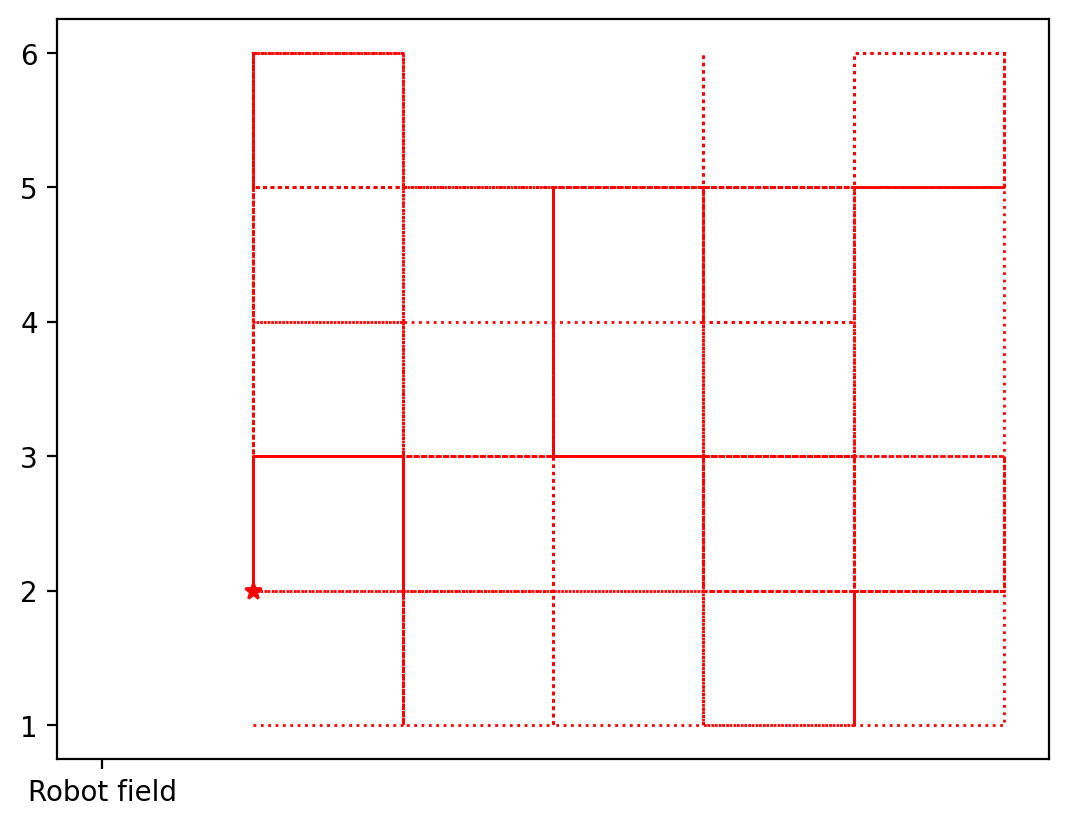

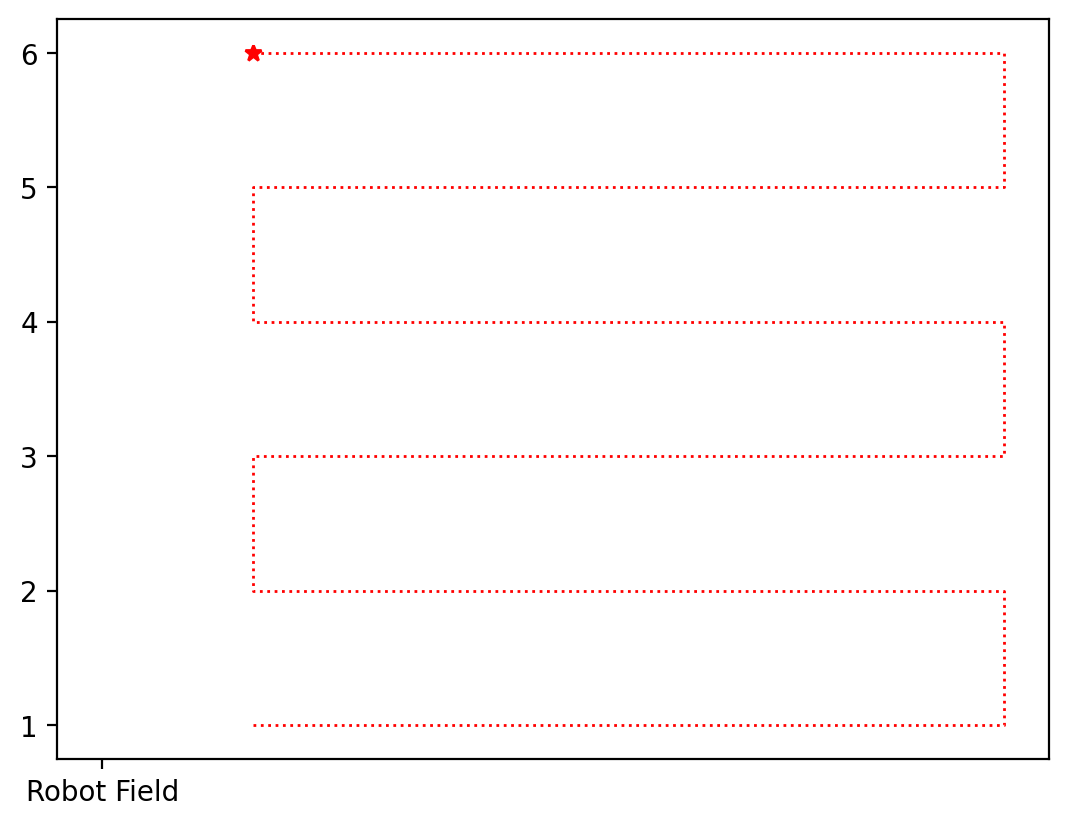

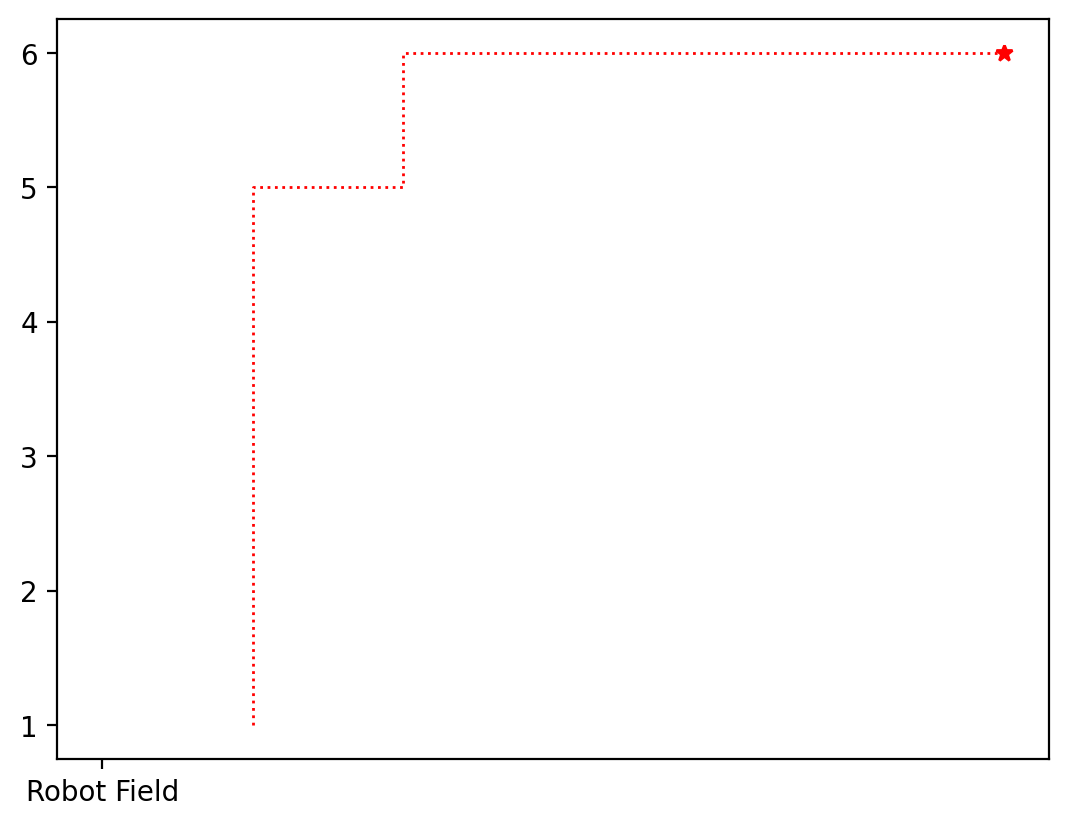

In [ ]:
import os, runpy
from pathlib import Path

# ---- CONFIG ----
SCRIPTS = ["simple_6x6.py", "model_6x6.py", "goal_6x6.py"]
OUTDIR = Path("q8_screenshots")
OUTDIR.mkdir(exist_ok=True)

# ---- Verify required files exist in the current working directory ----
required = SCRIPTS + ["Node.py"]
missing = [f for f in required if not Path(f).exists()]
print("Current working dir:", os.getcwd())
print("Files here:", sorted([p.name for p in Path(".").iterdir()]))

if missing:
    print("\nMissing files:", missing)
    print("Make sure ALL files are uploaded into the Colab Files panel (same folder).")
    raise SystemExit

# ---- Make matplotlib headless + deterministic ----
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

import random
random.seed(0)
try:
    import numpy as np
    np.random.seed(0)
except Exception:
    pass

def run_and_screenshot(script_path: str, out_png: Path):
    """
    Runs a script with a patched plt.show() that saves the most recent figure to out_png.
    """
    plt.close("all")
    original_show = plt.show

    def patched_show(*args, **kwargs):
        figs = [plt.figure(n) for n in plt.get_fignums()]
        if figs:
            fig = figs[-1]
            try:
                fig.canvas.draw()
            except Exception:
                pass
            fig.savefig(out_png, dpi=200, bbox_inches="tight")
        else:
            fig = plt.figure()
            fig.text(0.5, 0.5, f"No figure created by {script_path}", ha="center", va="center")
            fig.savefig(out_png, dpi=200, bbox_inches="tight")
        plt.close("all")

    plt.show = patched_show
    try:
        runpy.run_path(script_path, run_name="__main__")
    finally:
        plt.show = original_show

# ---- Run all scripts + save screenshots ----
saved = []
for s in SCRIPTS:
    out_png = OUTDIR / (Path(s).stem + "_screenshot.png")
    print(f"\nRunning {s} -> saving {out_png} ...")
    run_and_screenshot(s, out_png)
    saved.append(out_png)

print("\nDone. Saved screenshots:")
for p in saved:
    print(" -", p)

# ---- Display screenshots inline ----
from IPython.display import display, Image
for p in saved:
    display(Image(filename=str(p)))



8c. The simple reflex agent only reacts to what it senses in the current location. If the square is dirty, it cleans it; otherwise, it moves without remembering where it has already been, which can lead to repeated visits and wasted steps. The model-based agent improves on this by keeping an internal representation of the environment and following a systematic path, ensuring all locations are visited. The goal-based agent is the most intelligent because it explicitly works toward the goal of cleaning all dirty squares by planning its movement based on future outcomes, which generally reduces unnecessary actions and improves overall performance.